# Plymouth Geothermal Uncertainty Analysis

## 1. Imports

In [44]:
#import libraries
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

## 2. Project paths and inputs

In [45]:
#configure project paths
PROJECT_DIR = next(candidate for candidate in [Path.cwd().resolve(),*Path.cwd().resolve().parents] if (candidate / "01_Data").exists())
MODEL_OUTPUT_DIR = PROJECT_DIR / "01_Data/Processed/Geothermal/model_outputs"
ENERGY_PROCESSED_DIR = PROJECT_DIR / "01_Data/Processed/Energy"
MONTE_CARLO_OUTPUT_DIR = PROJECT_DIR / "01_Data/Processed/Geothermal/monte_carlo"
FIGURE_DIR = PROJECT_DIR / "03_Outputs/Figures"

for directory in [MONTE_CARLO_OUTPUT_DIR,FIGURE_DIR]:
    directory.mkdir(parents=True,exist_ok=True)



In [46]:
#load model inputs
CLOSED_LOOP_GPKG = MODEL_OUTPUT_DIR / "02_closed_loop_supply.gpkg"
CLOSED_LOOP_LAYER, BHE_GRID_LAYER = "closed_loop_supply", "bhe_grid_75m"
HEAT_DEMAND_GPKG = ENERGY_PROCESSED_DIR / "plymouth_heat_demand_2024.gpkg"
HEAT_DEMAND_LAYER = "lsoa_heat_demand_2024"

closed_loop = gpd.read_file(CLOSED_LOOP_GPKG,layer=CLOSED_LOOP_LAYER)
bhe_grid = gpd.read_file(CLOSED_LOOP_GPKG,layer=BHE_GRID_LAYER)
heat_demand = gpd.read_file(HEAT_DEMAND_GPKG,layer=HEAT_DEMAND_LAYER)

required_closed_loop = ["model_unit_lithology_id","LEX_D","RCS_D","model_area_m2","thermal_conductivity_w_mk",
                        "lambda_low_w_mk","lambda_high_w_mk","volumetric_heat_capacity_mj_m3k"]
required_bhe = ["bhe_id","grid_id","grid_spacing_m","model_unit_lithology_id","representative_useful_heat_mwh_year","geometry"]
required_demand = ["LSOA_code","LSOA","gas_consumption_kwh","offgas_useful_heat_kwh","total_useful_heat_mwh","geometry"]

for frame, columns, label in [(closed_loop,required_closed_loop,"closed_loop"),(bhe_grid,required_bhe,"bhe_grid"),(heat_demand,required_demand,"heat_demand")]:
    missing = [column for column in columns if column not in frame.columns]
    if missing:
        raise ValueError(f"{label} is missing required fields: {missing}")
if not (closed_loop.crs == bhe_grid.crs == heat_demand.crs):
    raise ValueError("CRS mismatch between geology, BHE grid and heat-demand layers.")


## 3. Monte Carlo assumptions

In [47]:
#set Monte Carlo assumptions
N_SIMULATIONS = 10_000
DEMAND_RANDOM_SEED = 42
CONDUCTIVITY_RANDOM_SEED = 20260827
HEAT_SHARE_RANGE = (0.95,0.975,1.00)
BOILER_EFFICIENCY_RANGE = (0.80,0.84,0.88)
GROUND_TEMPERATURE_C = 14.05
BOREHOLE_DEPTH_M = 150.0
BOREHOLE_RADIUS_M = 0.075
BOREHOLE_THERMAL_RESISTANCE_MK_W = 0.068
MIN_FLUID_TEMPERATURE_C = -2.0
HEATING_SEASON_DAYS = 182.0
SIMULATION_LIFETIME_YEARS = 50.0
HEAT_PUMP_SCOP = 3.2
ONE_YEAR_SECONDS = 365.25 * 24 * 3600
HEATING_SEASON_SECONDS = HEATING_SEASON_DAYS * 24 * 3600
SIMULATION_SECONDS = SIMULATION_LIFETIME_YEARS * ONE_YEAR_SECONDS
TC_RATIO = HEATING_SEASON_SECONDS / ONE_YEAR_SECONDS


## 4. Allocation and model functions

In [48]:
#assign BHE points to LSOAs
bhe_lsoa = gpd.sjoin(bhe_grid[["bhe_id","grid_id","grid_spacing_m","model_unit_lithology_id","geometry"]],
                     heat_demand[["LSOA_code","LSOA","geometry"]],how="left",predicate="within")
bhe_lsoa = bhe_lsoa.drop(columns=["index_right"]).reset_index(drop=True)

duplicate_assignments = int(bhe_lsoa["bhe_id"].duplicated().sum())
unassigned_bhes = int(bhe_lsoa["LSOA_code"].isna().sum())
if duplicate_assignments != 0:
    raise ValueError(f"Duplicate BHE-to-LSOA assignments: {duplicate_assignments}")
if unassigned_bhes != 0:
    raise ValueError(f"Unassigned 75 m BHE points: {unassigned_bhes}")


In [49]:
#define model functions
def calculate_heat_demand_mwh(heat_share_of_gas,boiler_efficiency):
    gas_useful_heat_kwh = heat_demand["gas_consumption_kwh"].to_numpy(dtype=float) * heat_share_of_gas * boiler_efficiency
    offgas_useful_heat_kwh = heat_demand["offgas_useful_heat_kwh"].to_numpy(dtype=float)
    return (gas_useful_heat_kwh + offgas_useful_heat_kwh) / 1_000

def calculate_geothermal_supply_mwh(lambda_w_mk,volumetric_heat_capacity_mj_m3k,ground_temperature_c=GROUND_TEMPERATURE_C,
                                     borehole_thermal_resistance_mk_w=BOREHOLE_THERMAL_RESISTANCE_MK_W,
                                     borehole_depth_m=BOREHOLE_DEPTH_M,heat_pump_scop=HEAT_PUMP_SCOP):
    lam = np.asarray(lambda_w_mk,dtype=float)
    cv = np.asarray(volumetric_heat_capacity_mj_m3k,dtype=float)
    if lam.shape != cv.shape:
        raise ValueError("Conductivity and volumetric heat-capacity arrays must match.")
    if np.any(lam <= 0) or np.any(cv <= 0):
        raise ValueError("Conductivity and heat capacity must be positive.")
    Cv = cv * 1_000_000
    alpha = lam / Cv
    u_s = BOREHOLE_RADIUS_M**2 / (4 * alpha * SIMULATION_SECONDS)
    u_c = BOREHOLE_RADIUS_M**2 / (4 * alpha * HEATING_SEASON_SECONDS)
    denominator = (-0.619 * TC_RATIO * np.log(u_s) + (0.532 * TC_RATIO - 0.962) * np.log(u_c)
                   - 0.455 * TC_RATIO - 1.619 + 4 * np.pi * lam * borehole_thermal_resistance_mk_w)
    q_bhe_w = 8 * (ground_temperature_c - MIN_FLUID_TEMPERATURE_C) * lam * borehole_depth_m * TC_RATIO / denominator
    ground_energy_mwh_per_bhe = q_bhe_w * 8760 / 1_000_000
    return ground_energy_mwh_per_bhe * heat_pump_scop / (heat_pump_scop - 1)

def triangular_vector_draw(rng,table):
    low = table["lambda_low_w_mk"].to_numpy(dtype=float)
    mode = table["thermal_conductivity_w_mk"].to_numpy(dtype=float)
    high = table["lambda_high_w_mk"].to_numpy(dtype=float)
    sampled = mode.copy()
    variable = high > low
    if variable.any():
        sampled[variable] = rng.triangular(left=low[variable],mode=mode[variable],right=high[variable])
    return sampled

def calculate_summary_metrics(demand_mwh,lsoa_supply_mwh):
    matched_mwh = np.minimum(lsoa_supply_mwh,demand_mwh)
    residual_mwh = np.maximum(demand_mwh - lsoa_supply_mwh,0)
    surplus_mwh = np.maximum(lsoa_supply_mwh - demand_mwh,0)
    total_demand_mwh = demand_mwh.sum()
    total_supply_mwh = lsoa_supply_mwh.sum()
    total_matched_mwh = matched_mwh.sum()
    return {"total_demand_gwh": total_demand_mwh / 1_000,
            "total_supply_gwh": total_supply_mwh / 1_000,
            "aggregate_supply_demand_pct": total_supply_mwh / total_demand_mwh * 100,
            "spatially_matched_heat_gwh": total_matched_mwh / 1_000,
            "spatially_matched_contribution_pct": total_matched_mwh / total_demand_mwh * 100,
            "residual_demand_gwh": residual_mwh.sum() / 1_000,
            "surplus_potential_gwh": surplus_mwh.sum() / 1_000}


## 5. Lithology and LSOA matrices

In [50]:
#prepare mapped lithology properties
thermal_columns = ["lambda_low_w_mk","thermal_conductivity_w_mk","lambda_high_w_mk"]
property_columns = [*thermal_columns,"volumetric_heat_capacity_mj_m3k"]
unit_consistency = closed_loop.groupby("model_unit_lithology_id")[property_columns].nunique(dropna=False)
if (unit_consistency > 1).any().any():
    bad_ids = unit_consistency.loc[(unit_consistency > 1).any(axis=1)]
    display(bad_ids)
    raise ValueError("At least one model_unit_lithology_id contains inconsistent thermal-property records.")

unit_table = closed_loop.groupby("model_unit_lithology_id")[["LEX_D","RCS_D",*property_columns]].first()
mapped_lithology_consistency = unit_table.groupby("RCS_D")[property_columns].nunique(dropna=False)
inconsistent_mapped_lithologies = mapped_lithology_consistency.loc[(mapped_lithology_consistency > 1).any(axis=1)]
if len(inconsistent_mapped_lithologies) > 0:
    display(inconsistent_mapped_lithologies)
    raise ValueError("At least one mapped lithology contains inconsistent thermal-property records.")

mapped_lithology_table = unit_table.groupby("RCS_D")[property_columns].first()
if len(mapped_lithology_table) != 16:
    raise ValueError(f"Expected 16 mapped lithologies, found {len(mapped_lithology_table)}.")
if not ((unit_table["lambda_low_w_mk"] <= unit_table["thermal_conductivity_w_mk"]).all() and
        (unit_table["thermal_conductivity_w_mk"] <= unit_table["lambda_high_w_mk"]).all()):
    raise ValueError("A conductivity range violates low <= mode <= high.")


In [51]:
#build the LSOA lithology count matrix
unit_position = pd.Series(np.arange(len(unit_table)),index=unit_table.index)
lsoa_position = pd.Series(np.arange(len(heat_demand)),index=heat_demand["LSOA_code"])
bhe_count_table = (bhe_lsoa.groupby(["LSOA_code","model_unit_lithology_id"],as_index=False)
                   .agg(bhe_count=("bhe_id","size")))
bhe_count_table["lsoa_position"] = bhe_count_table["LSOA_code"].map(lsoa_position)
bhe_count_table["unit_position"] = bhe_count_table["model_unit_lithology_id"].map(unit_position)
if bhe_count_table[["lsoa_position","unit_position"]].isna().any().any():
    raise ValueError("Could not map all BHE counts to array positions.")

bhe_count_matrix = np.zeros((len(heat_demand),len(unit_table)),dtype=float)
bhe_count_matrix[bhe_count_table["lsoa_position"].to_numpy(dtype=int),bhe_count_table["unit_position"].to_numpy(dtype=int)] = bhe_count_table["bhe_count"].to_numpy(dtype=float)
if int(bhe_count_matrix.sum()) != len(bhe_grid):
    raise AssertionError("BHE count matrix does not preserve the 75 m grid count.")

unit_cv = unit_table["volumetric_heat_capacity_mj_m3k"].to_numpy(dtype=float)
representative_lambda_unit = unit_table["thermal_conductivity_w_mk"].to_numpy(dtype=float)
baseline_lsoa_supply_mwh = bhe_count_matrix @ calculate_geothermal_supply_mwh(representative_lambda_unit,unit_cv)
exported_grid_supply_mwh = bhe_grid["representative_useful_heat_mwh_year"].sum()
if not np.isclose(baseline_lsoa_supply_mwh.sum(),exported_grid_supply_mwh):
    raise AssertionError("The deterministic G.POT recalculation does not reproduce the existing 75 m grid supply.")

mapped_lithology_position = pd.Series(np.arange(len(mapped_lithology_table)),index=mapped_lithology_table.index)
unit_to_mapped_lithology_pos = unit_table["RCS_D"].map(mapped_lithology_position).to_numpy(dtype=int)


## 6. Run uncertainty model

In [52]:
#draw demand assumptions
rng_demand = np.random.default_rng(DEMAND_RANDOM_SEED)
heat_share_draws = np.empty(N_SIMULATIONS,dtype=float)
boiler_efficiency_draws = np.empty(N_SIMULATIONS,dtype=float)

for simulation in range(N_SIMULATIONS):
    heat_share_draws[simulation] = rng_demand.triangular(*HEAT_SHARE_RANGE)
    boiler_efficiency_draws[simulation] = rng_demand.triangular(*BOILER_EFFICIENCY_RANGE)
    _ = triangular_vector_draw(rng_demand,unit_table)


In [53]:
#run the Monte Carlo model
rng_conductivity = np.random.default_rng(CONDUCTIVITY_RANDOM_SEED)
monte_carlo_rows = []
lambda_lithology_samples = np.empty((N_SIMULATIONS,len(mapped_lithology_table)),dtype=float)

for simulation in range(N_SIMULATIONS):
    heat_share = heat_share_draws[simulation]
    boiler_efficiency = boiler_efficiency_draws[simulation]
    demand_mwh = calculate_heat_demand_mwh(heat_share,boiler_efficiency)
    sampled_lambda_lithology = triangular_vector_draw(rng_conductivity,mapped_lithology_table)
    lambda_lithology_samples[simulation,:] = sampled_lambda_lithology
    sampled_lambda_unit = sampled_lambda_lithology[unit_to_mapped_lithology_pos]
    lsoa_supply_mwh = bhe_count_matrix @ calculate_geothermal_supply_mwh(sampled_lambda_unit,unit_cv)
    row = {"simulation": simulation + 1,"heat_share_of_gas": heat_share,"boiler_efficiency": boiler_efficiency}
    row.update(calculate_summary_metrics(demand_mwh,lsoa_supply_mwh))
    monte_carlo_rows.append(row)

monte_carlo_results = pd.DataFrame(monte_carlo_rows)
lambda_lithology_df = pd.DataFrame(lambda_lithology_samples,columns=mapped_lithology_table.index)


## 7. Summary and figures

In [54]:
#summarise uncertainty results
summary_metrics = {"Total residential heat demand (GWh/year)": "total_demand_gwh",
                   "Closed-loop useful heat supply (GWh/year)": "total_supply_gwh",
                   "Spatially matched heat (GWh/year)": "spatially_matched_heat_gwh",
                   "Heat-demand coverage (%)": "spatially_matched_contribution_pct",
                   "Residual heat demand (GWh/year)": "residual_demand_gwh",
                   "Surplus geothermal potential (GWh/year)": "surplus_potential_gwh"}
monte_carlo_summary = []
for metric,column in summary_metrics.items():
    values = monte_carlo_results[column]
    p5,p50,p95 = values.quantile([0.05,0.50,0.95])
    monte_carlo_summary.append({"metric": metric,"mean": values.mean(),"p5": p5,"p50": p50,"p95": p95,
                                "p5_p95_width": p95 - p5,"std_dev": values.std()})
monte_carlo_summary = pd.DataFrame(monte_carlo_summary)
display(monte_carlo_summary.round(4))


,metric,mean,p5,p50,p95,p5_p95_width,std_dev
0,Total residential heat demand (GWh/year),795.1050,768.7988,794.8568,822.0970,53.2982,16.1793
1,Closed-loop useful heat supply (GWh/year),392.2555,377.2314,392.9376,405.0612,27.8298,8.4495
2,Spatially matched heat (GWh/year),351.6320,340.9182,352.0335,360.8546,19.9364,6.0452
3,Heat-demand coverage (%),44.2398,42.4750,44.2507,45.9338,3.4587,1.0555
4,Residual heat demand (GWh/year),443.4730,417.3737,443.3309,470.2944,52.9208,16.0998
5,Surplus geothermal potential (GWh/year),40.6235,35.4945,40.8061,45.3102,9.8156,2.9823


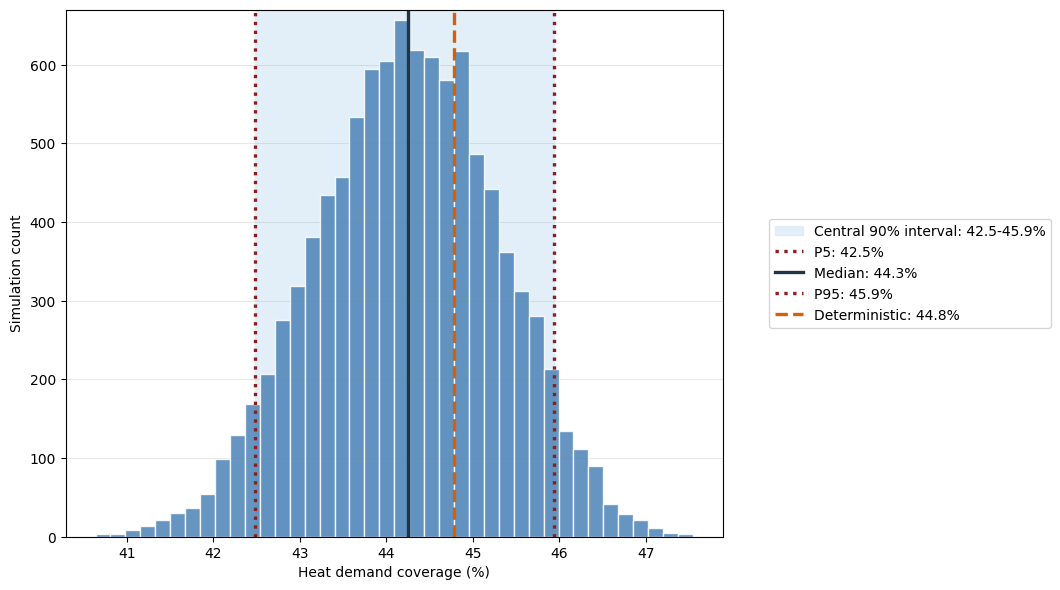

In [55]:
#plot coverage distribution
mc_coverage = monte_carlo_results["spatially_matched_contribution_pct"]
p5, median, p95 = mc_coverage.quantile([0.05,0.50,0.95])
deterministic_coverage = 44.7769168634367
city_summary_csv = MODEL_OUTPUT_DIR / "06_supply_demand_city_summary.csv"
if city_summary_csv.exists():
    city_summary = pd.read_csv(city_summary_csv)
    deterministic_coverage = city_summary.loc[city_summary["thermal_scenario"] == "representative","spatially_matched_contribution_pct"].iloc[0]

fig, ax = plt.subplots(figsize=(13.0,6.005))
ax.axvspan(p5,p95,color="#dcebf7",alpha=0.8,label=f"Central 90% interval: {p5:.1f}-{p95:.1f}%",zorder=0)
ax.hist(mc_coverage,bins=40,color="#4c83b6",edgecolor="white",alpha=0.85,zorder=2)
for value,color,linestyle,label in [(p5,"#8b1e1e",":",f"P5: {p5:.1f}%"),(median,"#20354a","-",f"Median: {median:.1f}%"),
                                     (p95,"#8b1e1e",":",f"P95: {p95:.1f}%"),(deterministic_coverage,"#d95f02","--",f"Deterministic: {deterministic_coverage:.1f}%")]:
    ax.axvline(value,color=color,linestyle=linestyle,linewidth=2.4,label=label)
ax.set_xlabel("Heat demand coverage (%)")
ax.set_ylabel("Simulation count")
ax.set_ylim(0,670)
ax.grid(axis="y",alpha=0.3)
ax.legend(loc="center left",bbox_to_anchor=(1.06,0.5),frameon=True)
fig.tight_layout(rect=[0,0,0.84,1])
fig.savefig(FIGURE_DIR / "Figure_4_8_MC_.png",dpi=200,facecolor="white")
plt.show()


In [56]:
#calculate PRCC sensitivity
def partial_rank_correlation(inputs_df,output_series):
    ranked_inputs = inputs_df.rank()
    ranked_output = output_series.rank()
    prcc_values = {}
    for column in ranked_inputs.columns:
        other_columns = [c for c in ranked_inputs.columns if c != column]
        design = np.column_stack([np.ones(len(ranked_inputs)),ranked_inputs[other_columns].to_numpy()])
        coef_input, *_ = np.linalg.lstsq(design,ranked_inputs[column].to_numpy(),rcond=None)
        residual_input = ranked_inputs[column].to_numpy() - design @ coef_input
        coef_output, *_ = np.linalg.lstsq(design,ranked_output.to_numpy(),rcond=None)
        residual_output = ranked_output.to_numpy() - design @ coef_output
        prcc_values[column] = np.corrcoef(residual_input,residual_output)[0,1]
    return prcc_values

def make_prcc_table(results,conductivity_samples):
    demand_inputs = results[["heat_share_of_gas","boiler_efficiency"]].reset_index(drop=True)
    variable_conductivity = conductivity_samples.loc[:,conductivity_samples.std() > 0].reset_index(drop=True)
    inputs = pd.concat([demand_inputs,variable_conductivity],axis=1)
    output = results["spatially_matched_contribution_pct"].reset_index(drop=True)
    prcc = partial_rank_correlation(inputs,output)
    rows = []
    for column in inputs.columns:
        rho,p_value = stats.spearmanr(inputs[column],output)
        rows.append({"input_parameter": column,"input_kind": "demand parameter" if column in ["heat_share_of_gas","boiler_efficiency"] else "mapped-lithology conductivity",
                     "spearman_rho": rho,"spearman_p_value": p_value,"prcc": prcc[column],"abs_prcc": abs(prcc[column])})
    return pd.DataFrame(rows).sort_values("abs_prcc",ascending=False).reset_index(drop=True)

prcc_table = make_prcc_table(monte_carlo_results,lambda_lithology_df)
display(prcc_table.head(12).round(4))


,input_parameter,input_kind,spearman_rho,spearman_p_value,prcc,abs_prcc
0,boiler_efficiency,demand parameter,-0.6150,0.0000,-0.9361,0.9361
1,SLATE,mapped-lithology conductivity,0.5827,0.0000,0.9300,0.9300
2,heat_share_of_gas,demand parameter,-0.3315,0.0000,-0.8170,0.8170
3,SLATE AND SILTSTONE,mapped-lithology conductivity,0.2688,0.0000,0.7468,0.7468
4,MUDSTONE AND SILTSTONE,mapped-lithology conductivity,0.2496,0.0000,0.7458,0.7458
5,LIMESTONE,mapped-lithology conductivity,0.0819,0.0000,0.2973,0.2973
6,"PYROCLASTIC-ROCK, BASALTIC",mapped-lithology conductivity,0.0464,0.0000,0.1832,0.1832
7,"LAVA, BASALTIC",mapped-lithology conductivity,0.0268,0.0075,0.1154,0.1154
8,"SANDSTONE, SILTSTONE AND MUDSTONE",mapped-lithology conductivity,0.0278,0.0054,0.1113,0.1113
9,GABBRO,mapped-lithology conductivity,0.0007,0.9444,0.0265,0.0265


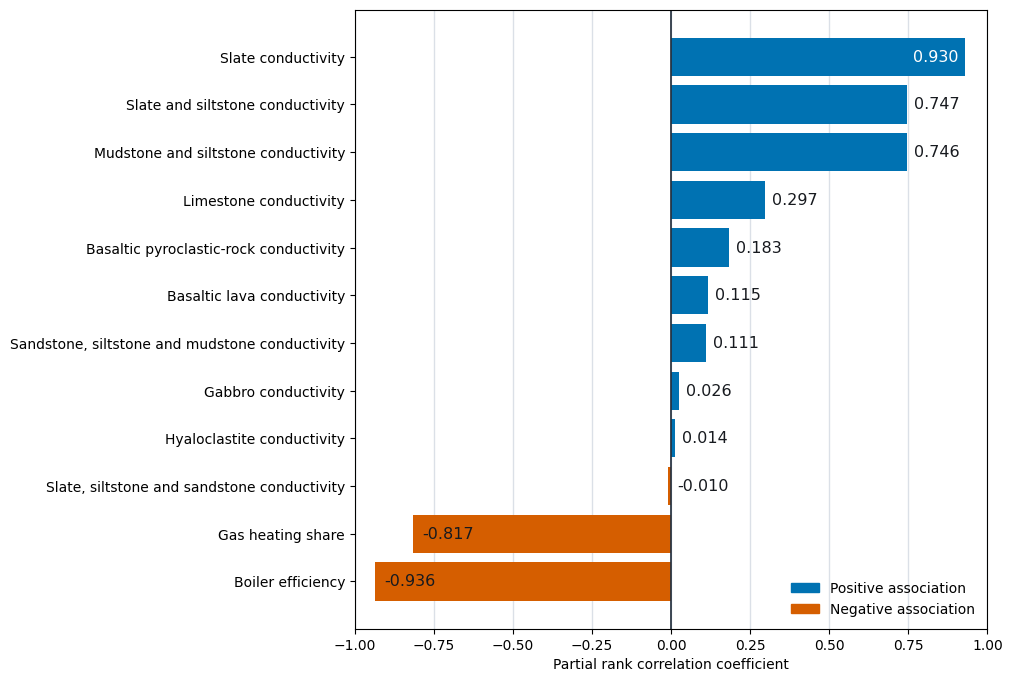

In [57]:
#plot PRCC sensitivity
from matplotlib.patches import Patch

TOP_N_PRCC_FIGURE = 12
label_lookup = {"heat_share_of_gas": "Gas heating share","boiler_efficiency": "Boiler efficiency"}
lithology_label_lookup = {"SLATE": "Slate conductivity","SLATE AND SILTSTONE": "Slate and siltstone conductivity",
                          "MUDSTONE AND SILTSTONE": "Mudstone and siltstone conductivity","LIMESTONE": "Limestone conductivity",
                          "PYROCLASTIC-ROCK, BASALTIC": "Basaltic pyroclastic-rock conductivity","LAVA, BASALTIC": "Basaltic lava conductivity",
                          "SANDSTONE, SILTSTONE AND MUDSTONE": "Sandstone, siltstone and mudstone conductivity","GABBRO": "Gabbro conductivity",
                          "HYALOCLASTITE": "Hyaloclastite conductivity","SLATE, SILTSTONE AND SANDSTONE": "Slate, siltstone and sandstone conductivity"}
prcc_plot_data = (prcc_table.dropna(subset=["prcc"]).sort_values("abs_prcc",ascending=False).head(TOP_N_PRCC_FIGURE).copy())
prcc_plot_data["plot_label"] = prcc_plot_data["input_parameter"].map(lambda value: label_lookup.get(value,lithology_label_lookup.get(value,str(value).title())))
prcc_plot_data = prcc_plot_data.sort_values("prcc")
positive_color, negative_color, axis_color = "#0072B2", "#D55E00", "#26313f"
fig, ax = plt.subplots(figsize=(11.0,7.2))
bar_colors = [positive_color if value >= 0 else negative_color for value in prcc_plot_data["prcc"]]
bars = ax.barh(prcc_plot_data["plot_label"],prcc_plot_data["prcc"],color=bar_colors)
ax.axvline(0,color=axis_color,linewidth=1.25)
ax.set_xlim(-1.0,1.0)
ax.set_xlabel("Partial rank correlation coefficient")
ax.grid(axis="x",color="#cfd6df",linewidth=1.0,alpha=0.75)
ax.set_axisbelow(True)
for bar,value in zip(bars,prcc_plot_data["prcc"]):
    if value >= 0 and value + 0.14 > 1.0:
        x,ha,label_color = value - 0.02,"right","white"
    elif value >= 0:
        x,ha,label_color = value + 0.022,"left","#171a1f"
    else:
        x,ha,label_color = value + 0.030,"left","#171a1f"
    ax.text(x,bar.get_y() + bar.get_height() / 2,f"{value:.3f}",va="center",ha=ha,fontsize=11.5,color=label_color)
ax.legend(handles=[Patch(color=positive_color,label="Positive association"),Patch(color=negative_color,label="Negative association")],loc="lower right",frameon=False)
fig.tight_layout()
fig.subplots_adjust(left=0.39,right=0.965,bottom=0.12,top=0.98)
fig.savefig(FIGURE_DIR / "Figure_4_9_PRCC_Sensitivity.png",dpi=300,facecolor="white")
plt.show()


In [58]:
#save Monte Carlo outputs
MONTE_CARLO_RESULTS_CSV = MONTE_CARLO_OUTPUT_DIR / "04_monte_carlo_results.csv"
MONTE_CARLO_SUMMARY_CSV = MONTE_CARLO_OUTPUT_DIR / "04_monte_carlo_summary.csv"
MONTE_CARLO_PRCC_CSV = MONTE_CARLO_OUTPUT_DIR / "04_prcc_sensitivity.csv"
MONTE_CARLO_LAMBDA_SAMPLES_CSV = MONTE_CARLO_OUTPUT_DIR / "04_mapped_lithology_lambda_samples.csv"

monte_carlo_results.to_csv(MONTE_CARLO_RESULTS_CSV,index=False)
monte_carlo_summary.to_csv(MONTE_CARLO_SUMMARY_CSV,index=False)
prcc_table.to_csv(MONTE_CARLO_PRCC_CSV,index=False)
lambda_lithology_df.to_csv(MONTE_CARLO_LAMBDA_SAMPLES_CSV,index=False)


## 8. Temperature scenarios and convergence

In [59]:
#run temperature scenarios
GROUND_TEMPERATURE_SCENARIOS_C = [12.0,14.05,16.3]
temperature_result_frames = {}

for ground_temperature_c in GROUND_TEMPERATURE_SCENARIOS_C:
    scenario_rows = []
    for simulation in range(N_SIMULATIONS):
        heat_share = heat_share_draws[simulation]
        boiler_efficiency = boiler_efficiency_draws[simulation]
        demand_mwh = calculate_heat_demand_mwh(heat_share,boiler_efficiency)
        sampled_lambda_unit = lambda_lithology_samples[simulation,:][unit_to_mapped_lithology_pos]
        lsoa_supply_mwh = bhe_count_matrix @ calculate_geothermal_supply_mwh(sampled_lambda_unit,unit_cv,ground_temperature_c=ground_temperature_c)
        row = {"simulation": simulation + 1,"ground_temperature_c": ground_temperature_c,
               "heat_share_of_gas": heat_share,"boiler_efficiency": boiler_efficiency}
        row.update(calculate_summary_metrics(demand_mwh,lsoa_supply_mwh))
        scenario_rows.append(row)
    temperature_result_frames[ground_temperature_c] = pd.DataFrame(scenario_rows)

temperature_monte_carlo_results = pd.concat(temperature_result_frames.values(),ignore_index=True)
baseline_temperature_results = temperature_result_frames[GROUND_TEMPERATURE_C]
if not all(np.allclose(baseline_temperature_results[column].to_numpy(dtype=float),monte_carlo_results[column].to_numpy(dtype=float),rtol=1e-12,atol=1e-12)
           for column in ["total_demand_gwh","total_supply_gwh","spatially_matched_heat_gwh","spatially_matched_contribution_pct"]):
    raise AssertionError("The 14.05 degC scenario does not reproduce the baseline Monte Carlo results.")


In [60]:
#summarise temperature scenarios
temperature_summary_rows = []
for ground_temperature_c,results in temperature_result_frames.items():
    for metric,column in summary_metrics.items():
        values = results[column]
        p5,p50,p95 = values.quantile([0.05,0.50,0.95])
        temperature_summary_rows.append({"ground_temperature_c": ground_temperature_c,"metric": metric,"mean": values.mean(),
                                         "p5": p5,"p50": p50,"p95": p95,"p5_p95_width": p95 - p5,"std_dev": values.std()})

temperature_monte_carlo_summary = pd.DataFrame(temperature_summary_rows)
temperature_metric_columns = {"Closed-loop useful heat supply (GWh/year)": "supply",
                           "Spatially matched heat (GWh/year)": "matched_heat",
                           "Heat-demand coverage (%)": "coverage"}
temperature_scenarios = []
for ground_temperature_c in GROUND_TEMPERATURE_SCENARIOS_C:
    subset = temperature_monte_carlo_summary.loc[temperature_monte_carlo_summary["ground_temperature_c"] == ground_temperature_c]
    scenario_row = {"ground_temperature_c": ground_temperature_c}
    for metric,short_name in temperature_metric_columns.items():
        metric_row = subset.loc[subset["metric"] == metric].iloc[0]
        for stat in ["p5","p50","p95","p5_p95_width"]:
            scenario_row[f"{short_name}_{stat}"] = metric_row[stat]
    temperature_scenarios.append(scenario_row)
temperature_scenarios = pd.DataFrame(temperature_scenarios)

temperature_coverage = temperature_scenarios[["ground_temperature_c","coverage_p5","coverage_p50","coverage_p95","coverage_p5_p95_width"]].copy()
temperature_coverage_range = pd.DataFrame([{"coverage_p5_min": temperature_coverage["coverage_p5"].min(),
                                   "coverage_p95_max": temperature_coverage["coverage_p95"].max(),
                                   "coverage_range_pp": temperature_coverage["coverage_p95"].max() - temperature_coverage["coverage_p5"].min()}])
display(temperature_scenarios.round(4))
display(temperature_coverage_range.round(4))


,ground_temperature_c,supply_p5,supply_p50,supply_p95,supply_p5_p95_width,matched_heat_p5,matched_heat_p50,matched_heat_p95,matched_heat_p5_p95_width,coverage_p5,coverage_p50,coverage_p95,coverage_p5_p95_width
0,12.00,329.0492,342.7493,353.3244,24.2752,303.7011,314.0524,322.0416,18.3404,37.8233,39.4747,41.0124,3.1891
1,14.05,377.2314,392.9376,405.0612,27.8298,340.9182,352.0335,360.8546,19.9364,42.4750,44.2507,45.9338,3.4587
2,16.30,430.1143,448.0223,461.8455,31.7312,379.1776,390.3165,399.5517,20.3741,47.2791,49.0749,50.7809,3.5017


,coverage_p5_min,coverage_p95_max,coverage_range_pp
0,37.8233,50.7809,12.9575


In [61]:
#check convergence
counts = [500,1000,2500,5000,7500,10000]
coverage_column = "spatially_matched_contribution_pct"
convergence_rows = []
for ground_temperature_c,results in temperature_result_frames.items():
    final_percentiles = np.percentile(results[coverage_column],[5,50,95])
    for n in counts:
        percentiles = np.percentile(results[coverage_column].iloc[:n],[5,50,95])
        convergence_rows.append({"ground_temperature_c": ground_temperature_c,"N": n,"P5": percentiles[0],"P50": percentiles[1],"P95": percentiles[2],
                                 "max_abs_difference_vs_10000_pp": np.max(np.abs(percentiles - final_percentiles))})
convergence_check = pd.DataFrame(convergence_rows)
convergence_5000 = convergence_check.loc[convergence_check["N"] == 5000,["ground_temperature_c","max_abs_difference_vs_10000_pp"]].copy()
display(convergence_5000.round(4))


,ground_temperature_c,max_abs_difference_vs_10000_pp
3,12.00,0.0427
9,14.05,0.0473
15,16.30,0.0413


In [62]:
#save temperature outputs
TEMPERATURE_SCENARIOS_CSV = MONTE_CARLO_OUTPUT_DIR / "04_temperature_scenarios.csv"
CONVERGENCE_CSV = MONTE_CARLO_OUTPUT_DIR / "04_convergence_check.csv"

temperature_scenarios.to_csv(TEMPERATURE_SCENARIOS_CSV,index=False)
convergence_check.to_csv(CONVERGENCE_CSV,index=False)


In [63]:
#export PRCC results table
TABLE_OUTPUT_DIR = PROJECT_DIR / "03_Outputs/Tables"
TABLE_OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

parameter_label_lookup = {"heat_share_of_gas": "Gas heating share","boiler_efficiency": "Boiler efficiency"}
input_ranges = {"heat_share_of_gas": HEAT_SHARE_RANGE,"boiler_efficiency": BOILER_EFFICIENCY_RANGE}
for lithology,row in mapped_lithology_table.iterrows():
    input_ranges[lithology] = (row["lambda_low_w_mk"],row["thermal_conductivity_w_mk"],row["lambda_high_w_mk"])

prcc_results_table = prcc_table.copy()
prcc_results_table["Parameter"] = (prcc_results_table["input_parameter"].map(
    lambda value: parameter_label_lookup.get(value,str(value).title().replace(" And "," and "))
).str.replace("Pyroclastic-Rock","Pyroclastic Rock",regex=False)
 .str.replace("Basaltic-Rock","Basaltic Rock",regex=False)
 .str.replace("Subequal/Subordinate","subequal/Subordinate",regex=False))
prcc_results_table["Minimum"] = prcc_results_table["input_parameter"].map(lambda value: input_ranges[value][0]).round(3)
prcc_results_table["Mode / representative value"] = prcc_results_table["input_parameter"].map(lambda value: input_ranges[value][1]).round(3)
prcc_results_table["Maximum"] = prcc_results_table["input_parameter"].map(lambda value: input_ranges[value][2]).round(3)
prcc_results_table["PRCC"] = prcc_results_table["prcc"].round(3)
prcc_results_table["Absolute PRCC rank"] = np.arange(1,len(prcc_results_table) + 1)
prcc_results_table = prcc_results_table[["Parameter","Minimum","Mode / representative value","Maximum","PRCC","Absolute PRCC rank"]]
prcc_results_table.to_csv(TABLE_OUTPUT_DIR / "PRCC_Results.csv",index=False)